In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("data", exist_ok=True)

In [2]:
CONFIDENCE_1 = 0.95
CONFIDENCE_2 = 0.99
TRADING_DAYS = 252

START = "2020-03-01"   # start date
END   = "2020-05-01" 

In [3]:
portfolio = pd.read_csv("data/portfolio_returns_log.csv", index_col=0, parse_dates=True)
asset_returns = pd.read_csv("data/returns_log.csv", index_col="Date", parse_dates=True)
prices = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)
#print(portfolio)

#print(weight)


In [4]:
# ---  First scenario : Historic case ---
if isinstance(portfolio, pd.DataFrame):
    portfolio = portfolio.iloc[:, 0]  
    
covid_portfolio = portfolio.loc[START:END].dropna()
print(f"Covid window: {START} -> {END} ({len(covid_portfolio)} days)")
#print(covid_portfolio.describe())

cum_return = np.exp(covid_portfolio.sum()) - 1
print("Cumulative return:", f"{cum_return:.2%}")

Covid window: 2020-03-01 -> 2020-05-01 (45 days)
Cumulative return: -17.80%


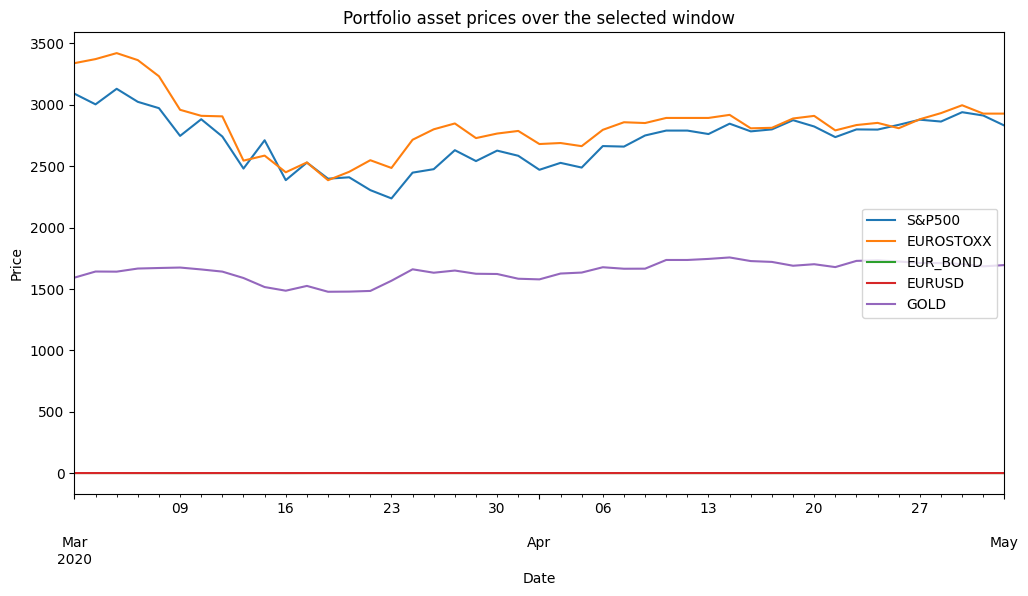

In [5]:

# display portfolio asset prices over the selected window
asset_prices_window = prices.loc[START:END]
#print(asset_prices_window)
asset_prices_window.plot(figsize=(12, 6))
plt.title("Portfolio asset prices over the selected window")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(loc="best")
plt.show()


In [6]:

covid_var_95 = np.percentile(covid_portfolio, (1 - CONFIDENCE_1) * 100)
covid_var_99 = np.percentile(covid_portfolio, (1 - CONFIDENCE_2) * 100)
covid_es_95 = covid_portfolio[covid_portfolio <= covid_var_95].mean()

print("Covid VaR 95%:", f"{covid_var_95:.2%}")
print("Covid VaR 99%:", f"{covid_var_99:.2%}")
print("Covid ES 95%:", f"{covid_es_95:.2%}")

Covid VaR 95%: -8.61%
Covid VaR 99%: -12.77%
Covid ES 95%: -11.48%


In [7]:
# max drawdown
port_cum = np.exp(portfolio.cumsum()) 
max_drawdown = -(port_cum / port_cum.cummax() - 1).min()
print("Max drawdown:", f"{max_drawdown:.2%}")

Max drawdown: 43.51%


In [8]:
#worst day
worst_day = portfolio.idxmin()
worst_return = portfolio.min()
print("Worst day:", worst_day.date()) # lockdown period
print("Worst return:", f"{worst_return:.2%}")

Worst day: 2020-03-09
Worst return: -13.45%
